In [78]:
import logging

logging.basicConfig(
    level=logging.DEBUG,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename='log.log',
    filemode='a'  
)

In [79]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [80]:
import importlib, helper, constant, cycle
importlib.reload(helper)
importlib.reload(constant)
importlib.reload(cycle)
from helper import get_text_labels, transform, write_reasoning_csv
from constant import LANGS, GAMES
from constant import MODEL_PROPERTIES, MODEL_W_REASONING_TRACE, KEYWORDS
from cycle import analyze_trace

In [81]:
%matplotlib inline

In [82]:
from typing import Literal
import json

# Main Score VS (all game * all lang)

A plot of 3x3 subplots, showing the distribution of Main Score across 2 categorical variables:  
* model type (open-weight / commercial): will be plotted on x-axis 
* reasoning (Y/N): will be plotted as different color of dots

Each dot represent the Main Score of a success episode; aborted episodes are not reflected. 

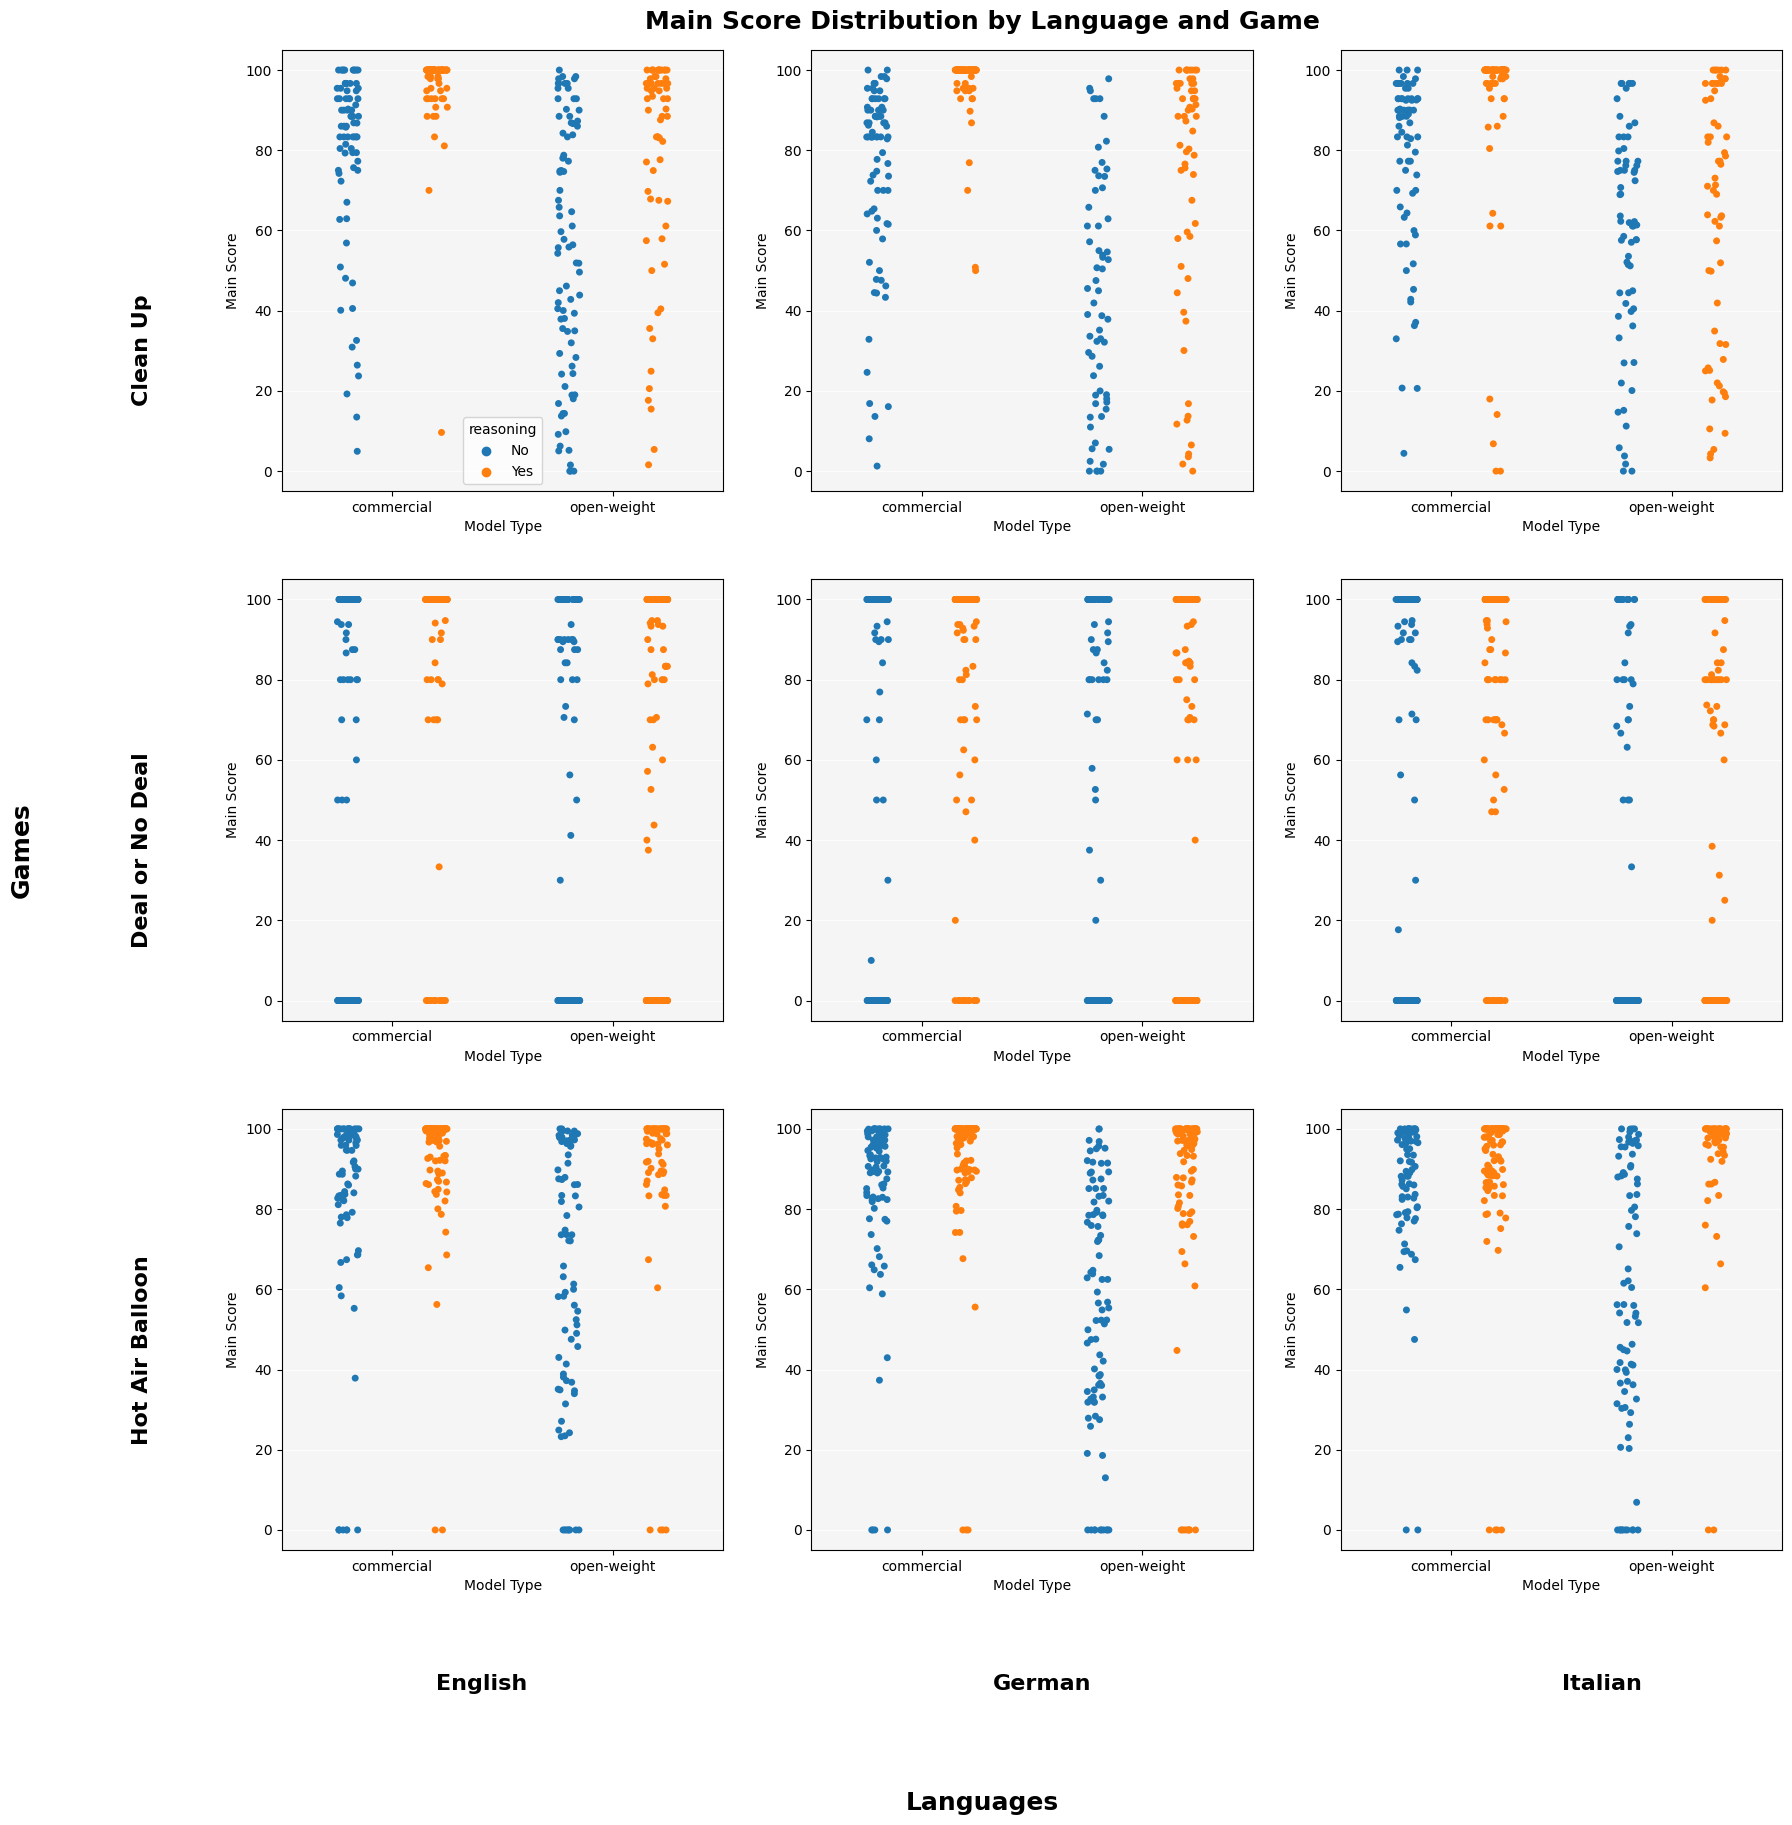

In [60]:
fig, axes = plt.subplots(
    nrows=len(GAMES), ncols=len(LANGS),
    figsize=(20, 20)
)

all_main_scores = []

for col_idx, (lang, lang_name) in enumerate(LANGS.items()):
    df = pd.read_csv(f"../results_{lang}/raw.csv")
    df_pv = transform(df)

    all_main_scores.extend(df_pv["Main Score"].dropna())

    for row_idx, (game, game_name) in enumerate(GAMES.items()):
        df_focus = df_pv.query("game == @game")
        ax = axes[row_idx, col_idx]

        ax.set_facecolor('whitesmoke')
        ax.grid(True, axis='y', linestyle='-', linewidth=1, color='white', alpha=0.8)
        ax.set_axisbelow(True)  
        ax.grid(True, axis='y')

        sns.stripplot(
            data=df_focus, x="Model Type", y="Main Score", hue="reasoning",
            dodge=True, jitter=True, ax=ax, legend=(row_idx == 0 and col_idx == 0)
        )

# Titles & labels
fig.suptitle("Main Score Distribution by Language and Game", fontsize=18, fontweight="bold", y=0.92)
fig.text(0.5, 0.02, "Languages", ha="center", fontsize=18, fontweight="bold")
fig.text(0.02, 0.5, "Games", ha="center", va="center", rotation=90, fontsize=18, fontweight="bold")

# Column labels
for col_idx, lang_name in enumerate(LANGS.values()):
    fig.text(0.25 + col_idx * 0.28, 0.08, lang_name, ha="center", fontsize=16, fontweight="bold")

# Row labels
for row_idx, game_name in enumerate(GAMES.values()):
    fig.text(0.08, 0.75 - row_idx * 0.25, game_name, ha="center", va="center",
             rotation=90, fontsize=16, fontweight="bold")

# plt.tight_layout(rect=[0.15, 0.15, 0.95, 0.9])
plt.subplots_adjust(left=0.15, bottom=0.15, top=0.9, hspace=0.2)  
plt.savefig("main_score_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()


# Main Score VS average length of reasoning chain

## Plotting Function Definition

In [83]:
def score_VS_reasoning(
                df, 
                x_var: Literal['reasoning_chain_avg_len', 'reasoning_chain_ratio'], 
                user_chosen_y_var: Literal['Main Score', 'clemscore'], 
                figure_name=None):
    """
    Plot user chosen metric on y-axis, against data about reasoning chain on x-axis. 

    Args: 
        df: 
        x_var: the variable on x-axis, could be one of the two: 
               - reasoning_chain_avg_len: average length of reasoning chain length 
               - reasoning_chain_ratio: number of sentences that has a reasoning label 
                 divided by number of all sentences, averaged across all reasoning traces in df
    """
    print(df.columns)
    # will always use 'Main Score' to get data from df
    # when 
    y_var = 'Main Score'  
    
    fig, axes = plt.subplots(
        nrows=len(GAMES), 
        ncols=len(KEYWORDS),
        figsize=(7, 15), 
        sharey=True, sharex=True
    )
    
    # turn on x-ticks for all subplots
    for ax in axes.flat:
        ax.tick_params(labelbottom=True)
    
    for col_idx, lang in enumerate(KEYWORDS.keys()):
        df_focus = df[df['lang'] == lang] 
        df_score = transform(pd.read_csv(f"../results_{lang}/raw.csv"))
        
        if user_chosen_y_var == 'clemscore': 
            # model's clemscore is just treating NaN as 0 and take average
            df_score['Main Score'].fillna(0, inplace=True)
    
        # prep df: reasoning chain data + scoring data for reasoning model
        df_main_raw = df_focus.merge(
                df_score,
                left_on=['model', 'game', 'experiment', 'episode'],
                right_on=['model', 'game', 'experiment', 'episode'],
                how='inner'  
            )[['model', 'game', 'experiment', 'episode', 
               'reasoning_chain_avg_len', 'reasoning_chain_ratio',
               'n_segment', 'cycle_edge_ratio', 'n_cycle_edges', 'n_total_edges',
               'Model Type', 'Main Score', 'Aborted', 'Success']]
    
        df_main = df_main_raw.groupby(['model', 'game'], as_index=False).agg({
                  'reasoning_chain_avg_len': 'mean', 
                  'reasoning_chain_ratio': 'mean', 
                  'n_segment': 'mean', 
                  'cycle_edge_ratio': 'mean', 
                  'n_cycle_edges': 'mean', 
                  'n_total_edges': 'mean',
                  'Main Score': 'mean', 
                  'Model Type': 'first'
                })
        
        # prep df: scoring data for non-reasoning counterpart models
        df_counterpart_raw = df_score[df_score['model'].isin([pair[0] for pair in model_pairs])]
        df_counterpart = df_counterpart_raw.groupby(['model', 'game'], as_index=False).agg({
            'Main Score': 'mean', 
            'Model Type': 'first'
        })
        df_counterpart['reasoning_chain_avg_len'] = 0    
        df_counterpart['reasoning_chain_ratio'] = 0  
        df_counterpart[['n_segment', 'cycle_edge_ratio', 'n_cycle_edges', 'n_total_edges']] = 0
    
        for row_idx, (game, game_name) in enumerate(GAMES.items()):
            # ax = axes[row_idx, col_idx]
            ax = axes[row_idx]
    
            ax.set_facecolor('whitesmoke')
            ax.set_axisbelow(True)  
            ax.grid(True, axis='y', linestyle='-', linewidth=1, color='white', alpha=0.8)
    
            # -- in each subplot: (1) plot the dots of reasoning model --
            df_main_game = df_main[df_main['game'] == game]
            sns.scatterplot(
                data=df_main_game, 
                x=x_var, y=y_var, 
                hue="model", 
                palette=custom_palette,
                style="Model Type", 
                markers=custom_markers,
                s=150, ax=ax, 
                zorder=5
            )
    
            # -- in each subplot: (2) plot the dots of non-reasoning model --
            df_counterpart_game = df_counterpart[df_counterpart['game'] == game]
            sns.scatterplot(
                data=df_counterpart_game, 
                x=x_var, y=y_var, 
                hue="model", 
                palette=custom_palette,
                style="Model Type", 
                markers=custom_markers,
                s=150, ax=ax, 
                zorder=5,
                alpha=0.4
            )
            
            ax.set_ylabel(user_chosen_y_var)            
    
            # -- in each subplot: (3) connect each pair of models --
            for cp_model, main_model in model_pairs: 
                if cp_model is None: 
                    continue 
                main_coords = df_main_game[df_main_game['model'] == main_model]
                x_main = main_coords[x_var].iloc[0]
                y_main = main_coords[y_var].iloc[0]
            
                cp_coords = df_counterpart_game[df_counterpart_game['model'] == cp_model]
                x_cp = cp_coords[x_var].iloc[0] # will be 0
                y_cp = cp_coords[y_var].iloc[0]
            
                ax.plot(
                    [x_main, x_cp],
                    [y_main, y_cp],
                    color='grey',
                    linestyle='--',
                    linewidth=1.5,
                    zorder=0 # Send lines behind the dots
                )
    
            # -- in each subplot: (4) add the conditional logic for the legend --
            if col_idx == 0 and row_idx == 0:
                # If it's the first subplot, create the custom marker legend
                handles, labels = ax.get_legend_handles_labels()
                num_styles = df_main_game['Model Type'].nunique()
                ax.legend(
                    handles=handles[-num_styles:], 
                    labels=labels[-num_styles:], 
                    title="Model Type"
                )
            else:
                if ax.get_legend() is not None:
                    ax.get_legend().remove()        
    
            # -- in each subplot: (5) annotate the dots for reasoning model only --
            for i, row in df_main_game.iterrows():
                ax.text(
                    row[x_var], 
                    row[y_var],              
                    row['model'],                       
                    fontsize=9, 
                    zorder=10
                )        
    
    # Titles & labels
    readable_x_var = {
        'reasoning_chain_avg_len': "Reasoning Chain average length",
        'reasoning_chain_ratio': "Reasoning Chain ratio", 
        'n_segment': "Number of Segment", 
        'cycle_edge_ratio': "Cyle Edge Ratio",  
        'n_cycle_edges': "Number of Cycle Edges", 
        'n_total_edges': "Number of Total Edges"
    }
    title = f"{user_chosen_y_var} VS {readable_x_var[x_var]}"
    
    fig.suptitle(title, fontsize=18, fontweight="bold", y=0.92)
    # fig.text(0.5, 0.02, "Languages", ha="center", fontsize=18, fontweight="bold")
    fig.text(0.01, 0.5, "Games", ha="center", va="center", rotation=90, fontsize=18, fontweight="bold")
    
    # # Column labels
    # for col_idx, lang_name in enumerate(KEYWORDS.keys()):
    #     fig.text(0.25 + col_idx * 0.28, 0.08, lang_name, ha="center", fontsize=16, fontweight="bold")
    
    # Row labels
    for row_idx, game_name in enumerate(GAMES.values()):
        fig.text(0.05, 0.8 - row_idx * 0.26, game_name, ha="center", va="center",
                 rotation=90, fontsize=16, fontweight="bold")
    
    plt.tight_layout(rect=[0.15, 0.15, 0.95, 0.9])
    plt.subplots_adjust(left=0.15, bottom=0.15, top=0.9, hspace=0.2)  
    plt.savefig(f"{('_').join((figure_name if figure_name is not None else title).split(' '))}.pdf" , dpi=300, bbox_inches="tight")
    plt.show()

def process_nested_list(nested_list):
    # a list of 4-tuple
    results = [analyze_trace(inner_list) for inner_list in nested_list]
    
    # Compute element-wise mean across all tuples
    arr = np.array(results)
    means = arr.mean(axis=0)
    
    return tuple(means)

## Prepare df

In [84]:
# # only need to execute once
write_reasoning_csv(log=True)


✓ Completed: reasoning_labels_per_episode.csv
[en-claude-sonnet-4-20250514-t0.0 1/98] Processing: dond/semi_en/instance_00001
[en-claude-sonnet-4-20250514-t0.0 2/98] Processing: dond/semi_en/instance_00004
[en-claude-sonnet-4-20250514-t0.0 3/98] Processing: dond/semi_en/instance_00005
[en-claude-sonnet-4-20250514-t0.0 4/98] Processing: dond/semi_en/instance_00000
[en-claude-sonnet-4-20250514-t0.0 5/98] Processing: dond/semi_en/instance_00008
[en-claude-sonnet-4-20250514-t0.0 6/98] Processing: dond/semi_en/instance_00019
[en-claude-sonnet-4-20250514-t0.0 7/98] Processing: dond/semi_en/instance_00017
[en-claude-sonnet-4-20250514-t0.0 8/98] Processing: dond/semi_en/instance_00012
[en-claude-sonnet-4-20250514-t0.0 9/98] Processing: dond/semi_en/instance_00016
[en-claude-sonnet-4-20250514-t0.0 10/98] Processing: dond/semi_en/instance_00014
[en-claude-sonnet-4-20250514-t0.0 11/98] Processing: dond/semi_en/instance_00010
[en-claude-sonnet-4-20250514-t0.0 12/98] Processing: dond/semi_en/insta

/home/ryang/UP/PM2/negotiation-games/common_plots/helper.py:183: RuntimeWarning: invalid value encountered in divide
  reasoning_chain_ratio = np.mean(np.array(reasoning_chain_len_r) / np.array(sent_counts))


[en-gpt-oss-120b-t1.0 52/101] Processing: hot_air_balloon/air_balloon_survival_en_complexity_easy/instance_00003
[en-gpt-oss-120b-t1.0 53/101] Processing: hot_air_balloon/air_balloon_survival_en_reasoning off_hard/instance_00004
[en-gpt-oss-120b-t1.0 54/101] Processing: hot_air_balloon/air_balloon_survival_en_reasoning off_hard/instance_00005
[en-gpt-oss-120b-t1.0 55/101] Processing: hot_air_balloon/air_balloon_survival_en_reasoning off_hard/instance_00002
[en-gpt-oss-120b-t1.0 56/101] Processing: hot_air_balloon/air_balloon_survival_en_reasoning off_hard/instance_00003
[en-gpt-oss-120b-t1.0 57/101] Processing: hot_air_balloon/air_balloon_survival_en_reasoning off_easy/instance_00001
[en-gpt-oss-120b-t1.0 58/101] Processing: hot_air_balloon/air_balloon_survival_en_reasoning off_easy/instance_00004
[en-gpt-oss-120b-t1.0 59/101] Processing: hot_air_balloon/air_balloon_survival_en_reasoning off_easy/instance_00005
[en-gpt-oss-120b-t1.0 60/101] Processing: hot_air_balloon/air_balloon_survi

In [85]:
df = pd.read_csv('reasoning_labels_per_episode.csv')
# in each cell is a list of thinking event, extracted from `interactions_with_thinking.json`, first turn only
# {
#     "from": "Player 1",
#     "to": "Player 1",
#     "timestamp": "2025-09-07T00:12:18.120277",
#     "action": {
#         "type": "thinking",
#         "content": "..."
#     }
# },
df["reasoning_raw"] = df["reasoning_raw"].apply(json.loads)
# list of thinking event -> list of list of labels
df["reasoning_labels"] = df["reasoning_labels"].apply(json.loads)

In [86]:
df.head()

,lang,model,game,experiment,episode,reasoning_raw,reasoning_labels,reasoning_chain_len,reasoning_chain_avg_len,reasoning_chain_ratio
0,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00001,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, PROPOSE], [CONCLUD...","[4, 4]",4.0,0.666667
1,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00004,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, CONCLUDE, PROPOSE]...","[5, 3]",4.0,0.716667
2,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00005,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[ASSERT, PROPOSE], [ASSERT, UNDERMINE, PROPOS...","[2, 4]",3.0,0.619048
3,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00000,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT], [CONCLUDE, ASSERT...","[3, 6]",4.5,0.803571
4,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00008,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, ASSERT], [PROPOSE,...","[4, 2]",3.0,0.600000


In [92]:
df[['n_segment', 'cycle_edge_ratio', 'n_cycle_edges', 'n_total_edges']] = df['reasoning_labels'].apply(
    lambda x: pd.Series(process_nested_list(x))
)

In [93]:
df.head()

,lang,model,game,experiment,episode,reasoning_raw,reasoning_labels,reasoning_chain_len,reasoning_chain_avg_len,reasoning_chain_ratio,n_segment,cycle_edge_ratio,n_cycle_edges,n_total_edges
0,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00001,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, PROPOSE], [CONCLUD...","[4, 4]",4.0,0.666667,1.0,0.00,0.0,0.0
1,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00004,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, CONCLUDE, PROPOSE]...","[5, 3]",4.0,0.716667,0.5,0.00,0.0,0.0
2,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00005,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[ASSERT, PROPOSE], [ASSERT, UNDERMINE, PROPOS...","[2, 4]",3.0,0.619048,1.0,0.25,0.5,1.0
3,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00000,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT], [CONCLUDE, ASSERT...","[3, 6]",4.5,0.803571,0.5,0.00,0.0,0.0
4,en,claude-sonnet-4-20250514-t0.0,dond,semi_en,instance_00008,"[{'from': 'Player 1', 'to': 'Player 1', 'times...","[[CONCLUDE, ASSERT, ASSERT, ASSERT], [PROPOSE,...","[4, 2]",3.0,0.600000,0.5,0.50,0.5,0.5


In [94]:
df.groupby(['model', 'game', 'lang'])['n_segment'].mean()

model                               game             lang
claude-sonnet-4-20250514-t0.0       clean_up         en       0.487654
                                    dond             en       0.737500
                                    hot_air_balloon  en       0.744624
deepseek-r1-distill-llama-70b-t1.0  clean_up         en       7.501998
                                    dond             en       9.200000
                                    hot_air_balloon  en      17.222222
gpt-oss-120b-t1.0                   clean_up         en       1.790123
                                    dond             en       2.125000
                                    hot_air_balloon  en       7.465686
nemotron-nano-9b-v2-t1.0            clean_up         en      15.562500
                                    dond             en      10.137500
                                    hot_air_balloon  en      31.104167
qwen3-next-80b-a3b-thinking-t1.0    clean_up         en      32.426667
                   

In [95]:
df.groupby(['model', 'game', 'lang'])['cycle_edge_ratio'].mean()

model                               game             lang
claude-sonnet-4-20250514-t0.0       clean_up         en      0.021605
                                    dond             en      0.112500
                                    hot_air_balloon  en      0.254032
deepseek-r1-distill-llama-70b-t1.0  clean_up         en      0.633945
                                    dond             en      0.928898
                                    hot_air_balloon  en      0.917601
gpt-oss-120b-t1.0                   clean_up         en      0.387844
                                    dond             en      0.822634
                                    hot_air_balloon  en      0.846077
nemotron-nano-9b-v2-t1.0            clean_up         en      0.788088
                                    dond             en      0.956345
                                    hot_air_balloon  en      0.861192
qwen3-next-80b-a3b-thinking-t1.0    clean_up         en      0.913356
                                

## constants for the plot

In [88]:
# non-reasonig - reasoning pairs; gpt-oss doesn't have a counterpart
model_pairs = [
    ("claude-sonnet-4-20250514-no-reasoning-t0.0", 'claude-sonnet-4-20250514-t0.0'), 
    ("llama-3.3-70b-instruct-t1.0", 'deepseek-r1-distill-llama-70b-t1.0'), 
    (None, 'gpt-oss-120b-t1.0'),
    ("nemotron-nano-9b-v2-no-reasoning-t1.0", 'nemotron-nano-9b-v2-t1.0'), 
    ("qwen3-next-80b-a3b-instruct-t1.0", 'qwen3-next-80b-a3b-thinking-t1.0')
]

In [89]:
# fix markers for Model Type, and colors for model
# no matter the order they appear in dataframe
custom_markers = {"commercial": "o", "open-weight": "X"} 

colors = sns.color_palette(n_colors=len(model_pairs))
custom_palette = {}
for (m1, m2), color in zip(model_pairs, colors): 
    custom_palette[m1] = color
    custom_palette[m2] = color 

## plot 1: clemscore VS cycle edge ratio

Index(['lang', 'model', 'game', 'experiment', 'episode', 'reasoning_raw',
       'reasoning_labels', 'reasoning_chain_len', 'reasoning_chain_avg_len',
       'reasoning_chain_ratio', 'n_segment', 'cycle_edge_ratio',
       'n_cycle_edges', 'n_total_edges'],
      dtype='object')


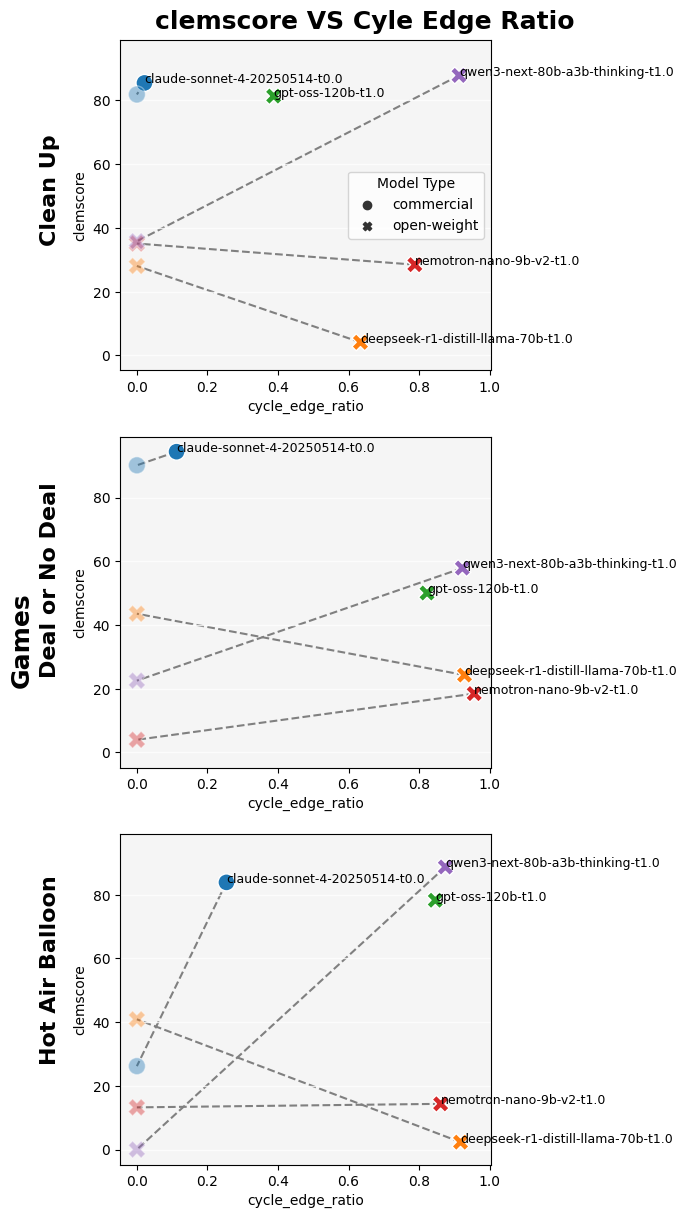

In [96]:
score_VS_reasoning(df, 'cycle_edge_ratio', 'clemscore')

## plot 2: clemscore VS n_segment

Index(['lang', 'model', 'game', 'experiment', 'episode', 'reasoning_raw',
       'reasoning_labels', 'reasoning_chain_len', 'reasoning_chain_avg_len',
       'reasoning_chain_ratio', 'n_segment', 'cycle_edge_ratio',
       'n_cycle_edges', 'n_total_edges'],
      dtype='object')


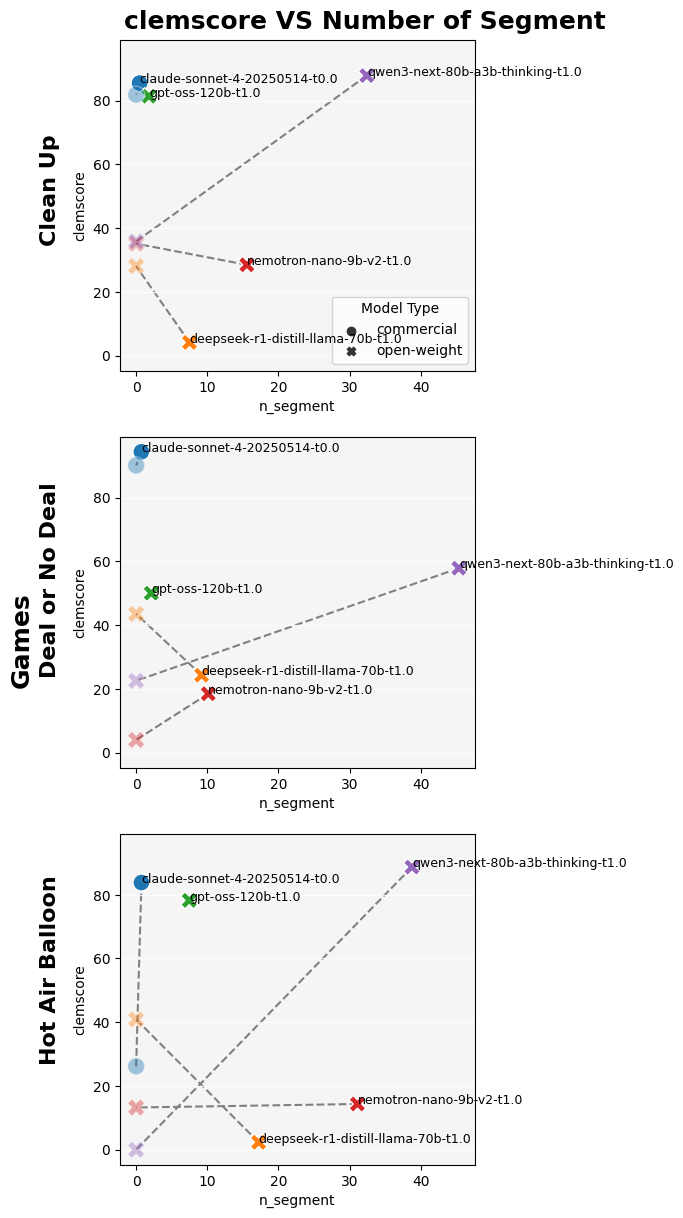

In [97]:
score_VS_reasoning(df, 'n_segment', 'clemscore')

# End